In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
file_path = '../data/raw/LD2011_2014.txt'

print("Loading dataset...")
df = pd.read_csv(file_path, 
                 sep=';',         
                 parse_dates=[0],   
                 index_col=0,       
                 decimal=',',       
                 low_memory=False)

print(f"\n Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows (time points): {df.shape[0]:,}")
print(f"Columns (households): {df.shape[1]:,}")
print(f"\nFirst 5 rows:")
print(df.head())

Loading dataset...

 Dataset loaded successfully!
Shape: (140256, 370)
Rows (time points): 140,256
Columns (households): 370

First 5 rows:
                     MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  MT_007  \
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

                     MT_008  MT_009  MT_010  ...  MT_361  MT_362  MT_363  \
2011-01-01 00:15:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-

In [3]:
df.columns = df.columns.str.replace('"', '')

print("Cleaned column names:")
print(f"Total households: {len(df.columns)}")
print(f"Sample households: {df.columns[:10].tolist()}")

Cleaned column names:
Total households: 370
Sample households: ['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007', 'MT_008', 'MT_009', 'MT_010']


In [4]:
print("\n=== DATA INFO ===")
print(f"Data types: {df.dtypes.value_counts().to_dict()}")
print(f"\nMissing values before cleaning: {df.isnull().sum().sum():,}")

# Check missing values per household
missing_per_household = df.isnull().sum()
print(f"\nHouseholds with missing values: {(missing_per_household > 0).sum()}")
print(f"Max missing per household: {missing_per_household.max()}")


=== DATA INFO ===
Data types: {dtype('float64'): 370}

Missing values before cleaning: 0

Households with missing values: 0
Max missing per household: 0


In [5]:
print("\nHandling missing values...")
original_missing = df.isnull().sum().sum()

df = df.fillna(method='ffill').fillna(method='bfill')

after_missing = df.isnull().sum().sum()
print(f"Missing values removed: {original_missing - after_missing:,}")

# Fill any remaining NaN with 0
df = df.fillna(0)


Handling missing values...
Missing values removed: 0


In [6]:
total_consumption = df.sum()

# Find households with zero total consumption
inactive_households = total_consumption[total_consumption == 0].index.tolist()
active_households = total_consumption[total_consumption > 0].index.tolist()

print(f"\n=== HOUSEHOLD STATUS ===")
print(f"Total households: {len(df.columns)}")
print(f"Active households: {len(active_households)}")
print(f"Inactive (zero consumption): {len(inactive_households)}")

# Keep only active households
df = df[active_households]
print(f"\nFinal dataset shape: {df.shape}")


=== HOUSEHOLD STATUS ===
Total households: 370
Active households: 370
Inactive (zero consumption): 0

Final dataset shape: (140256, 370)


In [7]:
stats_df = pd.DataFrame({
    'mean': df.mean(),
    'std': df.std(),
    'min': df.min(),
    'max': df.max(),
    'median': df.median()
})

print("\n=== CONSUMPTION STATISTICS ===")
print(stats_df.describe())

# Identify potential outliers (consumption > 100 kWh in 15-min interval)
high_consumption = (df > 100).sum().sum()
print(f"\nSuspicious high consumption readings (>100 kWh): {high_consumption:,}")



=== CONSUMPTION STATISTICS ===
               mean           std         min            max        median
count    370.000000    370.000000  370.000000     370.000000    370.000000
mean     528.532277    316.602729    0.507671    1750.244236    457.574301
std     2416.149483   2118.138560    1.555571   11034.768047   1864.856631
min        0.818058      2.260778    0.000000      22.613065      0.000000
25%       41.895166     29.873039    0.000000     167.863408     34.100512
50%      106.694350     57.757440    0.000000     315.047798    102.517439
75%      301.967730    129.807757    0.000000     806.285248    283.009215
max    37607.987537  38691.954832   15.243902  192800.000000  24100.000000

Suspicious high consumption readings (>100 kWh): 25,857,138


In [9]:
cleaned_path = '../data/processed/cleaned_data.csv'
df.to_csv(cleaned_path)
print(f"\n Cleaned data saved to: {cleaned_path}")

sample_df = df.iloc[:10000, :20]  
sample_path = '../data/processed/cleaned_data_sample.csv'
sample_df.to_csv(sample_path)
print(f" Sample data saved to: {sample_path}")



 Cleaned data saved to: ../data/processed/cleaned_data.csv
 Sample data saved to: ../data/processed/cleaned_data_sample.csv


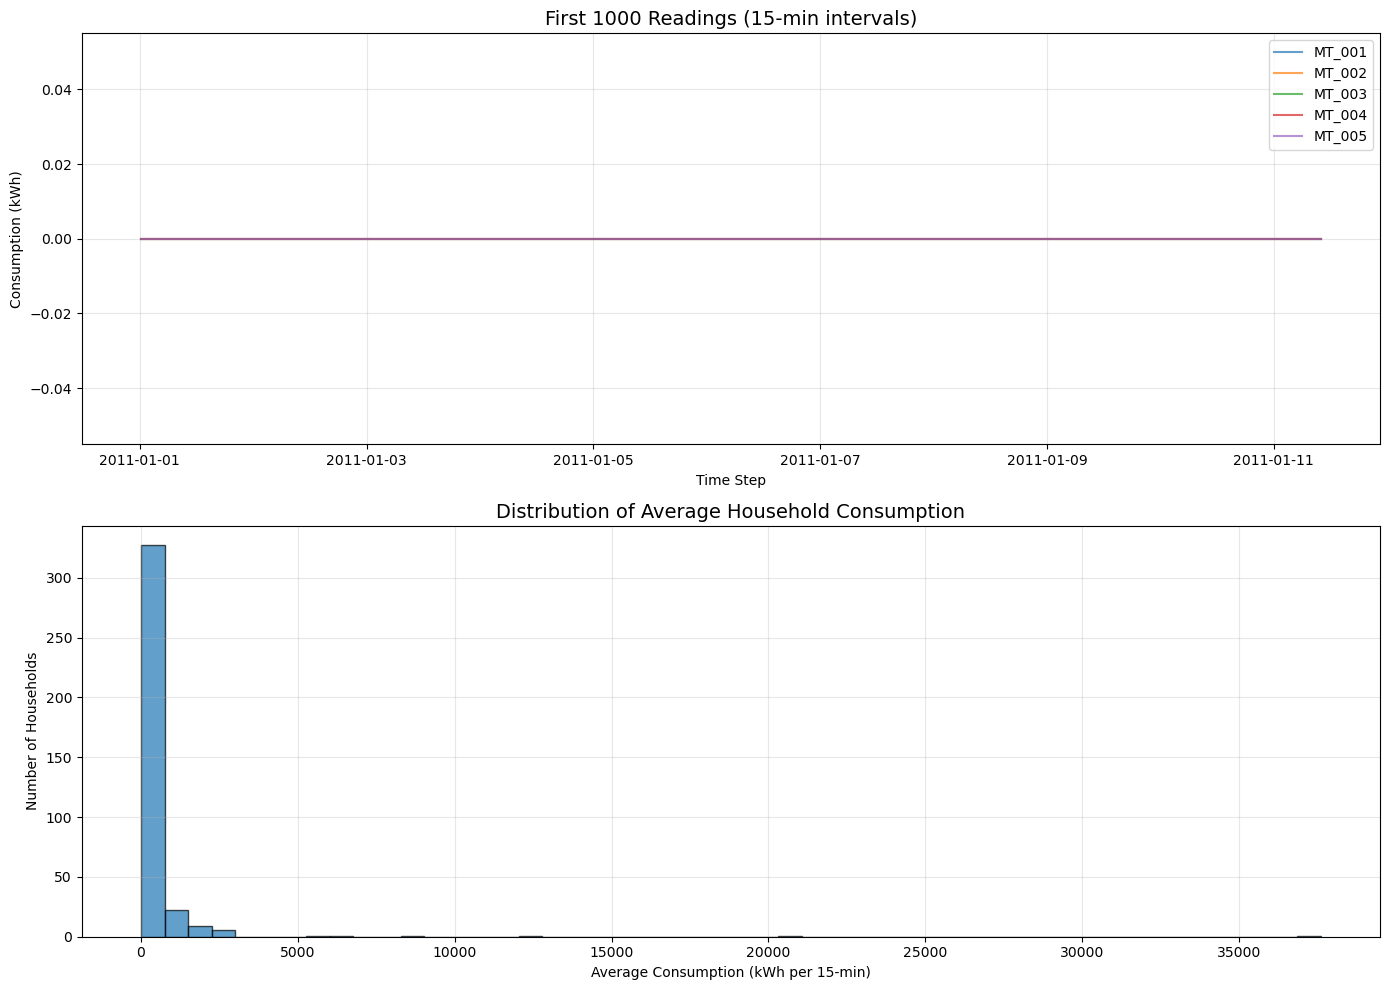

 Visualization saved!


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for household in df.columns[:5]:
    axes[0].plot(df[household].iloc[:1000], label=household, alpha=0.7)
axes[0].set_title('First 1000 Readings (15-min intervals)', fontsize=14)
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Consumption (kWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

avg_consumptions = df.mean()
axes[1].hist(avg_consumptions, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Average Household Consumption', fontsize=14)
axes[1].set_xlabel('Average Consumption (kWh per 15-min)')
axes[1].set_ylabel('Number of Households')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/consumption_overview.png', dpi=150)
plt.show()

print(" Visualization saved!")

In [12]:
print("\n" + "="*60)
print("DATA PREPROCESSING SUMMARY")
print("="*60)
print(f"""
| Metric                          | Value                    |
|---------------------------------|--------------------------|
| Original dataset shape          | {df.shape[0]:,} rows × {df.shape[1]:,} cols |
| Time span                       | {df.index.min()} to {df.index.max()} |
| Active households               | {len(active_households)} |
| Inactive households removed     | {len(inactive_households)} |
| Missing values handled          | {original_missing:,} |
| Final dataset shape             | {df.shape[0]:,} rows × {df.shape[1]:,} cols |
| Memory usage                    | {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB |
""")


summary = {
    'original_shape': (df.shape[0], df.shape[1]),
    'active_households': len(active_households),
    'time_start': str(df.index.min()),
    'time_end': str(df.index.max())
}

import json
with open('../data/processed/preprocessing_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)


DATA PREPROCESSING SUMMARY

| Metric                          | Value                    |
|---------------------------------|--------------------------|
| Original dataset shape          | 140,256 rows × 370 cols |
| Time span                       | 2011-01-01 00:15:00 to 2015-01-01 00:00:00 |
| Active households               | 370 |
| Inactive households removed     | 0 |
| Missing values handled          | 0 |
| Final dataset shape             | 140,256 rows × 370 cols |
| Memory usage                    | 397.00 MB |

